# Results Table
Aggregates metrics from all project result files into a single table.
Each row is one project (framework + project name).

**Aggregation strategy:**
- **SonarQube**: taken directly from the project-level `sonarqube_project` field
- **Halstead** (raw counts + volume): summed across files
- **Halstead** (derived: difficulty, effort, time_seconds, bugs_delivered, calculated_length): median across files
- **State metrics** (mutable_vars, immutable_vars, observable_state_vars, state_updates): summed across files
- **Derived metrics** (mutable_variable_ratio): computed as sum(mutable_vars) / sum(total_vars) across files
- **Derived metrics** (maintainability_index): median across files

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# --- Plot style ---
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'legend.frameon': False,
    'savefig.bbox': 'tight',
    'savefig.dpi': 300,
})

COLORS = {'compose': '#4C72B0', 'views': '#DD8452'}  # blue / orange
FIGURES_DIR = Path('../results/figures')
#FIGURES_DIR.mkdir(exist_ok=True)

In [2]:
RESULTS_DIR = Path('../results')

result_files = sorted(
    f for f in RESULTS_DIR.glob('*.json')
    if f.stem.startswith('compose_') or f.stem.startswith('views_')
)
print(f'Found {len(result_files)} result files:')
for f in result_files:
    print(f'  {f.name}')

Found 16 result files:
  compose_architecture-samples-compose.json
  compose_dicio-android.json
  compose_gallery.json
  compose_jetcaster.json
  compose_nowinandroid.json
  compose_pokedex-compose.json
  compose_sunflower.json
  compose_tivi.json
  views_Simple-Gallery.json
  views_Simple-Music-Player.json
  views_apps-android-wikipedia.json
  views_architecture-samples-views.json
  views_dicio-android-views.json
  views_pokedex.json
  views_showly.json
  views_sunflower_views.json


In [3]:
SONARQUBE_FIELDS = [
    'ncloc', 'lines', 'files', 'functions', 'classes', 'statements',
    'complexity', 'cognitive_complexity',
    'code_smells', 'bugs', 'sqale_debt_ratio',
    'duplicated_lines_density', 'comment_lines', 'comment_lines_density',
]

# Summed: raw counts + volume (volume is additive in Halstead theory)
HALSTEAD_SUM_FIELDS = [
    'loc',
    'n1_unique_operators', 'n2_unique_operands',
    'N1_total_operators', 'N2_total_operands',
    'vocabulary', 'length', 'volume',
]

# Median: derived metrics that are not additive
HALSTEAD_MEDIAN_FIELDS = [
    'calculated_length', 'difficulty', 'effort',
    'time_seconds', 'bugs_delivered',
]

STATE_SUM_FIELDS = [
    'mutable_vars', 'immutable_vars',
    'observable_state_vars', 'state_updates',
]

DERIVED_MEDIAN_FIELDS = [
    'maintainability_index',
]

# --- Project pairs ---
# Each entry: (fw_a, proj_a, display_color_a, fw_b, proj_b, display_color_b, bg_color)
# Project names match Path(project_path).name from the JSON files.
PAIRS = [
    ('compose', 'Gallery',                     COLORS['compose'], 'views', 'Simple-Gallery',              COLORS['views'], '#FFE4B5'),
    ('compose', 'nowinandroid',                COLORS['compose'], 'views', 'apps-android-wikipedia',      COLORS['views'], '#B0E0E6'),
    ('compose', 'Jetcaster',                   COLORS['compose'], 'views', 'Simple-Music-Player',         COLORS['views'], '#DDA0DD'),
    ('compose', 'sunflower',                   COLORS['compose'], 'views', 'sunflower_views',             COLORS['views'], '#ADDFAD'),
    ('compose', 'architecture-samples-compose',COLORS['compose'], 'views', 'architecture-samples-views',  COLORS['views'], '#F08080'),
    ('compose', 'pokedex-compose',             COLORS['compose'], 'views', 'Pokedex',                     COLORS['views'], '#FAFAD2'),
    ('compose', 'dicio-android',               COLORS['compose'], 'views', 'dicio-android-views',         COLORS['views'], '#E6E6FA'),
    ('compose', 'tivi',                        COLORS['compose'], 'views', 'showly',                      COLORS['views'], '#98FB98'),
]

In [4]:
def collect_file_values(files_dict, section, fields):
    """Collect non-null values for `fields` from a named sub-section of each file entry."""
    collected = {f: [] for f in fields}
    for file_data in files_dict.values():
        if not isinstance(file_data, dict):
            continue
        section_data = file_data.get(section, {})
        if not isinstance(section_data, dict):
            continue
        for field in fields:
            val = section_data.get(field)
            if val is not None:
                try:
                    collected[field].append(float(val))
                except (TypeError, ValueError):
                    pass
    return collected


def aggregate_project(data):
    row = {}
    # Use the last component of project_path as the canonical project name
    project_path = data.get('project_path', '')
    row['project']   = Path(project_path).name if project_path else data.get('project', '')
    row['framework'] = data.get('framework', '')

    sq = data.get('sonarqube_project', {})
    for field in SONARQUBE_FIELDS:
        val = sq.get(field)
        row[f'sq_{field}'] = float(val) if val is not None else None

    files_dict = data.get('files', {})

    hal = collect_file_values(files_dict, 'halstead', HALSTEAD_SUM_FIELDS + HALSTEAD_MEDIAN_FIELDS)
    for field in HALSTEAD_SUM_FIELDS:
        vals = hal[field]
        row[f'hal_{field}'] = sum(vals) if vals else None
    for field in HALSTEAD_MEDIAN_FIELDS:
        vals = hal[field]
        row[f'hal_{field}'] = float(np.median(vals)) if vals else None

    state = collect_file_values(files_dict, 'state_metrics', STATE_SUM_FIELDS)
    for field in STATE_SUM_FIELDS:
        vals = state[field]
        row[f'state_{field}'] = sum(vals) if vals else None

    # mutable_variable_ratio: computed from summed totals (not median of per-file ratios,
    # which breaks when >50% of files have 0 mutable vars — median collapses to 0)
    total_mutable = row.get('state_mutable_vars') or 0
    total_immutable = row.get('state_immutable_vars') or 0
    total_vars = total_mutable + total_immutable
    row['derived_mutable_variable_ratio'] = round(total_mutable / total_vars, 4) if total_vars > 0 else None

    derived = collect_file_values(files_dict, 'derived', DERIVED_MEDIAN_FIELDS)
    for field in DERIVED_MEDIAN_FIELDS:
        vals = derived[field]
        row[f'derived_{field}'] = float(np.median(vals)) if vals else None

    return row


rows = []
for result_file in result_files:
    with open(result_file) as f:
        data = json.load(f)
    rows.append(aggregate_project(data))

df = pd.DataFrame(rows).set_index(['framework', 'project'])
print(f'Table shape: {df.shape}')
print(df.index.tolist())
df

Table shape: (16, 33)
[('compose', 'architecture-samples-compose'), ('compose', 'dicio-android'), ('compose', 'Gallery'), ('compose', 'Jetcaster'), ('compose', 'nowinandroid'), ('compose', 'pokedex-compose'), ('compose', 'sunflower'), ('compose', 'tivi'), ('views', 'Simple-Gallery'), ('views', 'Simple-Music-Player'), ('views', 'apps-android-wikipedia'), ('views', 'architecture-samples-views'), ('views', 'dicio-android-views'), ('views', 'Pokedex'), ('views', 'showly'), ('views', 'sunflower_views')]


sq_ncloc   sq_lines  sq_files  \
framework project                                                        
compose   architecture-samples-compose   4185.000   7218.000    87.000   
          dicio-android                 23242.000  28066.000   310.000   
          Gallery                       60908.000  68622.000   496.000   
          Jetcaster                     14927.000  21182.000   272.000   
          nowinandroid                  20890.000  33389.000   413.000   
          pokedex-compose                3862.000   7094.000   142.000   
          sunflower                      3680.000   6422.000    98.000   
          tivi                          26609.000  36630.000   748.000   
views     Simple-Gallery                41964.000  47194.000   293.000   
          Simple-Music-Player           16456.000  19320.000   251.000   
          apps-android-wikipedia       301904.000 324919.000  1966.000   
          architecture-samples-views     4413.000   7648.000    91.000   
          dicio-android-views            9782.000  11729.000   195.000   
          Pokedex                        2614.000   5038.000    91.000   
          showly                       112042.000 127743.000  2197.000   
          sunflower_views                3181.000   5989.000   117.000   

                                        sq_functions  sq_classes  \
framework project                                                  
compose   architecture-samples-compose       248.000      57.000   
          dicio-android                      782.000     296.000   
          Gallery                           1267.000     413.000   
          Jetcaster                          488.000     159.000   
          nowinandroid                       853.000     308.000   
          pokedex-compose                    165.000      85.000   
          sunflower                          144.000      58.000   
          tivi                              1250.000     794.000   
views     Simple-Gallery                    1097.000     108.000   
          Simple-Music-Player                726.000     109.000   
          apps-android-wikipedia            6443.000    2066.000   
          architecture-samples-views         350.000      50.000   
          dicio-android-views                332.000      95.000   
          Pokedex                            108.000      52.000   
          showly                            3703.000    1705.000   
          sunflower_views                    127.000      59.000   

                                        sq_statements  sq_complexity  \
framework project                                                      
compose   architecture-samples-compose       1272.000        306.000   
          dicio-android                      4829.000       1656.000   
          Gallery                           11211.000       3435.000   
          Jetcaster                          2564.000        763.000   
          nowinandroid                       4491.000       1231.000   
          pokedex-compose                     688.000        235.000   
          sunflower                           702.000        193.000   
          tivi                               5143.000       2192.000   
views     Simple-Gallery                     9608.000       3869.000   
          Simple-Music-Player                4099.000       1485.000   
          apps-android-wikipedia            37738.000      13565.000   
          architecture-samples-views         1488.000        433.000   
          dicio-android-views                2049.000        673.000   
          Pokedex                             398.000        146.000   
          showly                            23927.000       7685.000   
          sunflower_views                     456.000        164.000   

                                        sq_cognitive_complexity  \
framework project                                                 
compose   architecture-samples-compose              

## SonarQube metrics

In [5]:
sq_cols = [c for c in df.columns if c.startswith('sq_')]
df[sq_cols].rename(columns=lambda c: c[3:])

ncloc      lines    files  \
framework project                                                       
compose   architecture-samples-compose   4185.000   7218.000   87.000   
          dicio-android                 23242.000  28066.000  310.000   
          Gallery                       60908.000  68622.000  496.000   
          Jetcaster                     14927.000  21182.000  272.000   
          nowinandroid                  20890.000  33389.000  413.000   
          pokedex-compose                3862.000   7094.000  142.000   
          sunflower                      3680.000   6422.000   98.000   
          tivi                          26609.000  36630.000  748.000   
views     Simple-Gallery                41964.000  47194.000  293.000   
          Simple-Music-Player           16456.000  19320.000  251.000   
          apps-android-wikipedia       301904.000 324919.000 1966.000   
          architecture-samples-views     4413.000   7648.000   91.000   
          dicio-android-views            9782.000  11729.000  195.000   
          Pokedex                        2614.000   5038.000   91.000   
          showly                       112042.000 127743.000 2197.000   
          sunflower_views                3181.000   5989.000  117.000   

                                        functions  classes  statements  \
framework project                                                        
compose   architecture-samples-compose    248.000   57.000    1272.000   
          dicio-android                   782.000  296.000    4829.000   
          Gallery                        1267.000  413.000   11211.000   
          Jetcaster                       488.000  159.000    2564.000   
          nowinandroid                    853.000  308.000    4491.000   
          pokedex-compose                 165.000   85.000     688.000   
          sunflower                       144.000   58.000     702.000   
          tivi                           1250.000  794.000    5143.000   
views     Simple-Gallery                 1097.000  108.000    9608.000   
          Simple-Music-Player             726.000  109.000    4099.000   
          apps-android-wikipedia         6443.000 2066.000   37738.000   
          architecture-samples-views      350.000   50.000    1488.000   
          dicio-android-views             332.000   95.000    2049.000   
          Pokedex                         108.000   52.000     398.000   
          showly                         3703.000 1705.000   23927.000   
          sunflower_views                 127.000   59.000     456.000   

                                        complexity  cognitive_complexity  \
framework project                                                          
compose   architecture-samples-compose     306.000                87.000   
          dicio-android                   1656.000              1256.000   
          Gallery                         3435.000              4498.000   
          Jetcaster                        763.000               409.000   
          nowinandroid                    1231.000               592.000   
          pokedex-compose                  235.000                96.000   
          sunflower                        193.000                63.000   
          tivi                            2192.000              1215.000   
views     Simple-Gallery                  3869.000              4114.000   
          Simple-Music-Player             1485.000              1187.000   
          apps-android-wikipedia         13565.000             10854.000   
          architecture-samples-views       433.000               101.000   
          dicio-android-views              673.000               625.000   
          Pokedex                          146.000                39.000   
          showly                          7685.000              5179.000   
          sunflower_views                  164.000                36.000   

                           

## Halstead metrics

In [6]:
hal_cols = [c for c in df.columns if c.startswith('hal_')]
df[hal_cols].rename(columns=lambda c: c[4:])

loc  n1_unique_operators  \
framework project                                                       
compose   architecture-samples-compose  1416.000              121.000   
          dicio-android                 7673.000              921.000   
          Gallery                      36311.000             3838.000   
          Jetcaster                    11718.000             1019.000   
          nowinandroid                  8498.000              681.000   
          pokedex-compose               2280.000              324.000   
          sunflower                     1961.000              177.000   
          tivi                          3358.000              669.000   
views     Simple-Gallery               15443.000             1395.000   
          Simple-Music-Player           4821.000              862.000   
          apps-android-wikipedia       24816.000             3158.000   
          architecture-samples-views     797.000              153.000   
          dicio-android-views           2363.000              369.000   
          Pokedex                        568.000              118.000   
          showly                        3867.000              802.000   
          sunflower_views                747.000              158.000   

                                        n2_unique_operands  \
framework project                                            
compose   architecture-samples-compose             742.000   
          dicio-android                           5019.000   
          Gallery                                22253.000   
          Jetcaster                               6024.000   
          nowinandroid                            4119.000   
          pokedex-compose                         1369.000   
          sunflower                               1127.000   
          tivi                                    2330.000   
views     Simple-Gallery                          9681.000   
          Simple-Music-Player                     4622.000   
          apps-android-wikipedia                 18977.000   
          architecture-samples-views               504.000   
          dicio-android-views                     1515.000   
          Pokedex                                  375.000   
          showly                                  3208.000   
          sunflower_views                          511.000   

                                        N1_total_operators  N2_total_operands  \
framework project                                                               
compose   architecture-samples-compose            1516.000           1832.000   
          dicio-android                          10420.000          11570.000   
          Gallery                                50174.000          58442.000   
          Jetcaster                              13111.000          15306.000   
          nowinandroid                            8749.000          10612.000   
          pokedex-compose                         2712.000           3107.000   
          sunflower                               2162.000           2461.000   
          tivi                                    4224.000           4718.000   
views     Simple-Gallery                         28772.000          29867.000   
          Simple-Music-Player                     9947.000          10585.000   
          apps-android-wikipedia                 46094.000          50532.000   
          architecture-samples-views               926.000            938.000   
          dicio-android-views                     3621.000           3656.000   
          Pokedex                                  600.000            670.000   
          showly                                  6700.000           7128.000   
          sunflower_views                          792.000            829.000   

                                        vocabulary     length     volume  \
framework project                                                          
co

## State metrics (summed across files)

In [7]:
state_cols = [c for c in df.columns if c.startswith('state_')]
df[state_cols].rename(columns=lambda c: c[6:])

mutable_vars  immutable_vars  \
framework project                                                      
compose   architecture-samples-compose         2.000          21.000   
          dicio-android                       37.000         384.000   
          Gallery                            286.000        2323.000   
          Jetcaster                           17.000         531.000   
          nowinandroid                        34.000         351.000   
          pokedex-compose                      6.000          58.000   
          sunflower                            2.000         122.000   
          tivi                                10.000         122.000   
views     Simple-Gallery                     416.000        1259.000   
          Simple-Music-Player                 59.000         332.000   
          apps-android-wikipedia             323.000        1140.000   
          architecture-samples-views          12.000          37.000   
          dicio-android-views                 53.000         135.000   
          Pokedex                              6.000          22.000   
          showly                              66.000         228.000   
          sunflower_views                      3.000          28.000   

                                        observable_state_vars  state_updates  
framework project                                                             
compose   architecture-samples-compose                  2.000          3.000  
          dicio-android                                21.000         51.000  
          Gallery                                     223.000        559.000  
          Jetcaster                                    21.000         21.000  
          nowinandroid                                 19.000         60.000  
          pokedex-compose                               3.000         24.000  
          sunflower                                     2.000          3.000  
          tivi                                         11.000         27.000  
views     Simple-Gallery                               13.000        857.000  
          Simple-Music-Player                          13.000        192.000  
          apps-android-wikipedia                       26.000        740.000  
          architecture-samples-views                    5.000         26.000  
          dicio-android-views                           0.000        115.000  
          Pokedex                                       1.000          8.000  
          showly                                        0.000         46.000  
          sunflower_views                               0.000          5.000

## Derived metrics (median across files)

In [8]:
derived_cols = [c for c in df.columns if c.startswith('derived_')]
df[derived_cols].rename(columns=lambda c: c[8:])

mutable_variable_ratio  \
framework project                                                
compose   architecture-samples-compose                   0.087   
          dicio-android                                  0.088   
          Gallery                                        0.110   
          Jetcaster                                      0.031   
          nowinandroid                                   0.088   
          pokedex-compose                                0.094   
          sunflower                                      0.016   
          tivi                                           0.076   
views     Simple-Gallery                                 0.248   
          Simple-Music-Player                            0.151   
          apps-android-wikipedia                         0.221   
          architecture-samples-views                     0.245   
          dicio-android-views                            0.282   
          Pokedex                                        0.214   
          showly                                         0.225   
          sunflower_views                                0.097   

                                        maintainability_index  
framework project                                              
compose   architecture-samples-compose                 29.660  
          dicio-android                                33.880  
          Gallery                                      33.430  
          Jetcaster                                    34.770  
          nowinandroid                                 30.575  
          pokedex-compose                              41.790  
          sunflower                                    34.785  
          tivi                                         42.600  
views     Simple-Gallery                               30.540  
          Simple-Music-Player                          31.385  
          apps-android-wikipedia                       30.660  
          architecture-samples-views                   38.290  
          dicio-android-views                          29.730  
          Pokedex                                      41.855  
          showly                                       36.290  
          sunflower_views                              38.900

## Full table

In [9]:
df

sq_ncloc   sq_lines  sq_files  \
framework project                                                        
compose   architecture-samples-compose   4185.000   7218.000    87.000   
          dicio-android                 23242.000  28066.000   310.000   
          Gallery                       60908.000  68622.000   496.000   
          Jetcaster                     14927.000  21182.000   272.000   
          nowinandroid                  20890.000  33389.000   413.000   
          pokedex-compose                3862.000   7094.000   142.000   
          sunflower                      3680.000   6422.000    98.000   
          tivi                          26609.000  36630.000   748.000   
views     Simple-Gallery                41964.000  47194.000   293.000   
          Simple-Music-Player           16456.000  19320.000   251.000   
          apps-android-wikipedia       301904.000 324919.000  1966.000   
          architecture-samples-views     4413.000   7648.000    91.000   
          dicio-android-views            9782.000  11729.000   195.000   
          Pokedex                        2614.000   5038.000    91.000   
          showly                       112042.000 127743.000  2197.000   
          sunflower_views                3181.000   5989.000   117.000   

                                        sq_functions  sq_classes  \
framework project                                                  
compose   architecture-samples-compose       248.000      57.000   
          dicio-android                      782.000     296.000   
          Gallery                           1267.000     413.000   
          Jetcaster                          488.000     159.000   
          nowinandroid                       853.000     308.000   
          pokedex-compose                    165.000      85.000   
          sunflower                          144.000      58.000   
          tivi                              1250.000     794.000   
views     Simple-Gallery                    1097.000     108.000   
          Simple-Music-Player                726.000     109.000   
          apps-android-wikipedia            6443.000    2066.000   
          architecture-samples-views         350.000      50.000   
          dicio-android-views                332.000      95.000   
          Pokedex                            108.000      52.000   
          showly                            3703.000    1705.000   
          sunflower_views                    127.000      59.000   

                                        sq_statements  sq_complexity  \
framework project                                                      
compose   architecture-samples-compose       1272.000        306.000   
          dicio-android                      4829.000       1656.000   
          Gallery                           11211.000       3435.000   
          Jetcaster                          2564.000        763.000   
          nowinandroid                       4491.000       1231.000   
          pokedex-compose                     688.000        235.000   
          sunflower                           702.000        193.000   
          tivi                               5143.000       2192.000   
views     Simple-Gallery                     9608.000       3869.000   
          Simple-Music-Player                4099.000       1485.000   
          apps-android-wikipedia            37738.000      13565.000   
          architecture-samples-views         1488.000        433.000   
          dicio-android-views                2049.000        673.000   
          Pokedex                             398.000        146.000   
          showly                            23927.000       7685.000   
          sunflower_views                     456.000        164.000   

                                        sq_cognitive_complexity  \
framework project                                                 
compose   architecture-samples-compose              

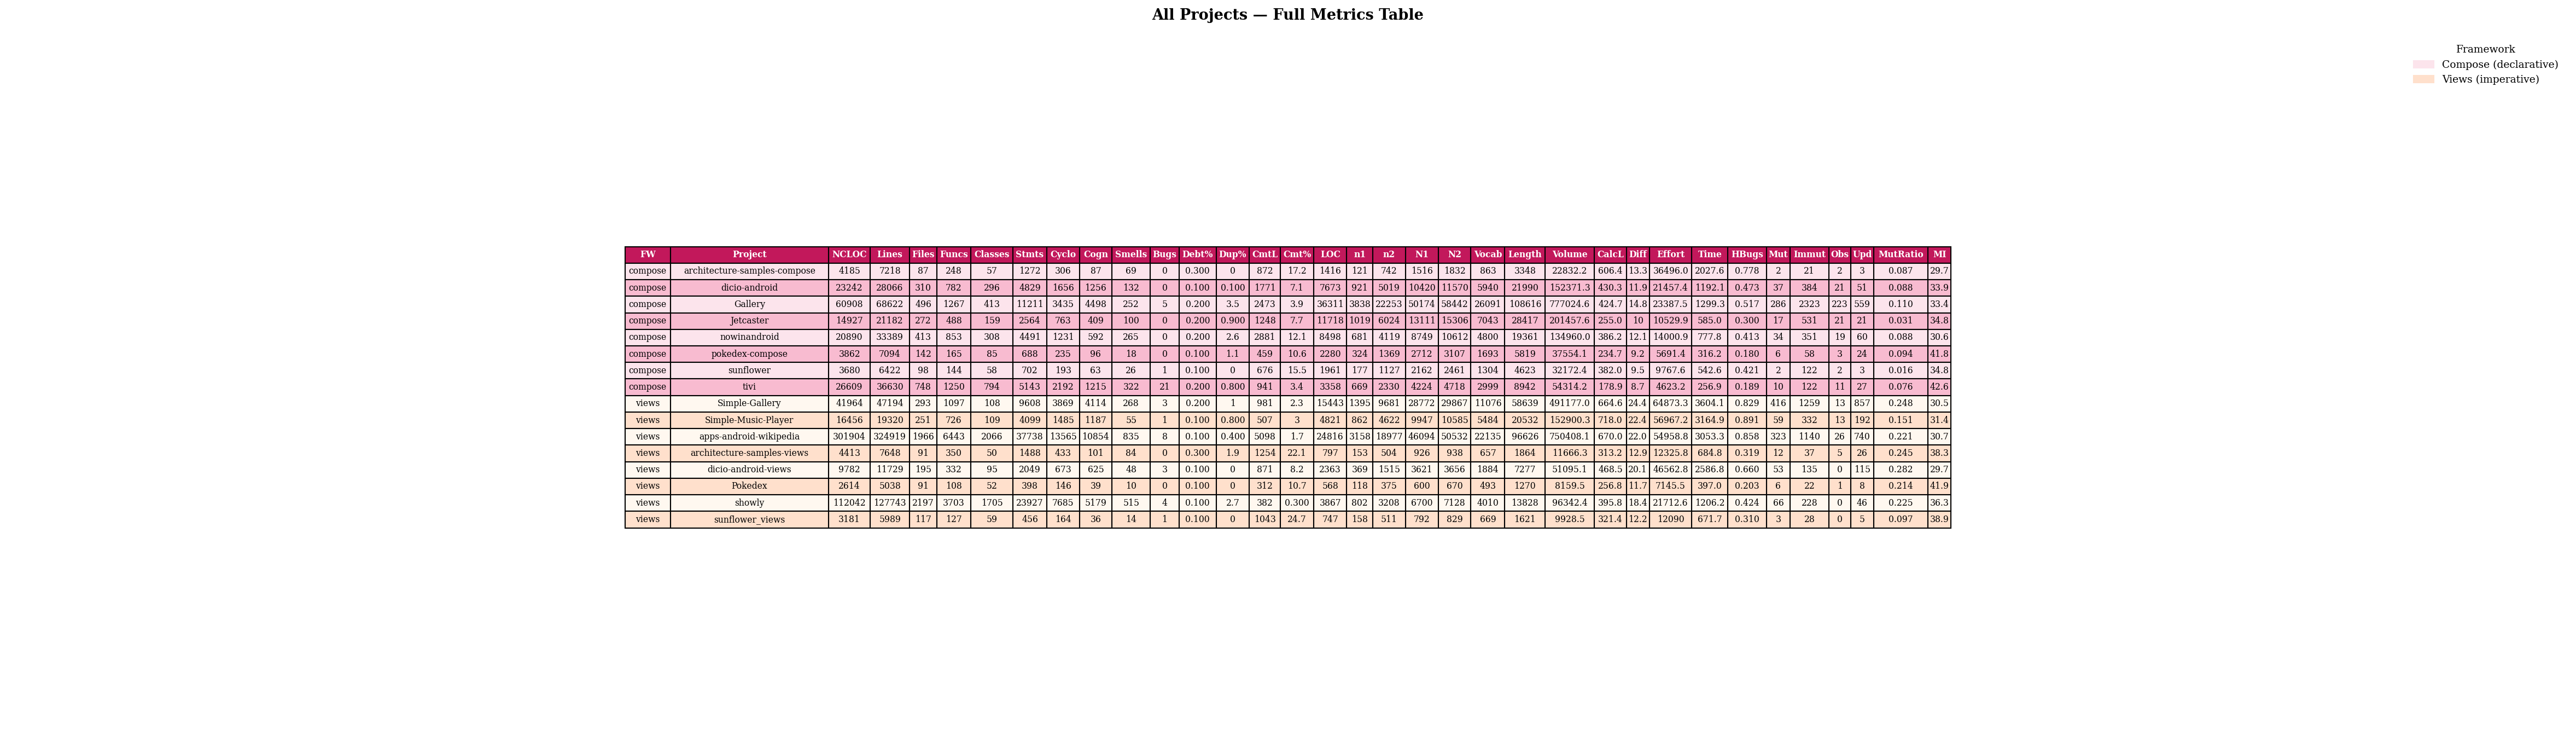

In [10]:
SHORT_NAMES = {
    'framework': 'FW', 'project': 'Project',
    'sq_ncloc': 'NCLOC', 'sq_lines': 'Lines', 'sq_files': 'Files',
    'sq_functions': 'Funcs', 'sq_classes': 'Classes', 'sq_statements': 'Stmts',
    'sq_complexity': 'Cyclo', 'sq_cognitive_complexity': 'Cogn',
    'sq_code_smells': 'Smells', 'sq_bugs': 'Bugs', 'sq_sqale_debt_ratio': 'Debt%',
    'sq_duplicated_lines_density': 'Dup%', 'sq_comment_lines': 'CmtL',
    'sq_comment_lines_density': 'Cmt%',
    'hal_loc': 'LOC', 'hal_n1_unique_operators': 'n1', 'hal_n2_unique_operands': 'n2',
    'hal_N1_total_operators': 'N1', 'hal_N2_total_operands': 'N2',
    'hal_vocabulary': 'Vocab', 'hal_length': 'Length', 'hal_volume': 'Volume',
    'hal_calculated_length': 'CalcL', 'hal_difficulty': 'Diff',
    'hal_effort': 'Effort', 'hal_time_seconds': 'Time', 'hal_bugs_delivered': 'HBugs',
    'state_mutable_vars': 'Mut', 'state_immutable_vars': 'Immut',
    'state_observable_state_vars': 'Obs', 'state_state_updates': 'Upd',
    'derived_mutable_variable_ratio': 'MutRatio', 'derived_maintainability_index': 'MI',
}

HEADER_PINK   = '#C2185B'   # deep pink — header row
COMPOSE_PINK  = '#FCE4EC'   # light pink — compose rows
COMPOSE_PINK2 = '#F8BBD0'   # slightly darker pink — compose alternating
VIEWS_CREAM   = '#FFF8F0'   # near-white cream — views rows
VIEWS_CREAM2  = '#FFE0CC'   # light peach — views alternating

df_plot = df.reset_index()

def fmt_val(v):
    if pd.isna(v):
        return '—'
    if isinstance(v, float) and v == int(v) and abs(v) < 1e9:
        return str(int(v))
    if isinstance(v, float) and abs(v) < 1:
        return f'{v:.3f}'
    if isinstance(v, float):
        return f'{v:.1f}'
    return str(v)

col_labels  = [SHORT_NAMES.get(c, c) for c in df_plot.columns]
cell_text   = [[fmt_val(v) for v in row] for row in df_plot.itertuples(index=False)]

# Row colors: alternate within each framework group
cell_colors = []
compose_idx = 0
views_idx   = 0
for _, row in df_plot.iterrows():
    if row['framework'] == 'compose':
        color = COMPOSE_PINK if compose_idx % 2 == 0 else COMPOSE_PINK2
        compose_idx += 1
    else:
        color = VIEWS_CREAM if views_idx % 2 == 0 else VIEWS_CREAM2
        views_idx += 1
    cell_colors.append([color] * len(col_labels))

n_cols = len(col_labels)
n_rows = len(cell_text)
fig_w  = max(22, n_cols * 0.9)
fig_h  = max(6,  n_rows * 0.45 + 2.0)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis('off')

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellColours=cell_colors,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.auto_set_column_width(col=list(range(n_cols)))

for j in range(n_cols):
    tbl[0, j].set_facecolor(HEADER_PINK)
    tbl[0, j].set_text_props(color='white', fontweight='bold')

compose_patch = mpatches.Patch(color=COMPOSE_PINK,  label='Compose (declarative)')
views_patch   = mpatches.Patch(color=VIEWS_CREAM2,  label='Views (imperative)')
ax.legend(handles=[compose_patch, views_patch], fontsize=9,
          loc='upper right', title='Framework', title_fontsize=9)

ax.set_title('All Projects — Full Metrics Table', fontsize=13, fontweight='bold', pad=14)
fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'full_metrics_table.png', dpi=200, bbox_inches='tight')
plt.show()

---
# Plots

In [11]:
def build_plot_order(pairs, df):
    """
    Returns:
      order      - list of (framework, project) tuples in display order
      tick_labels- short project name for x-axis
      bar_colors - display bar color per entry (independent of df framework)
      bg_spans   - list of (x_start, x_end, color) for pair background shading
    """
    order, tick_labels, bar_colors, bg_spans = [], [], [], []
    x = 0
    for fw_a, proj_a, color_a, fw_b, proj_b, color_b, bg_color in pairs:
        group_start = x
        if (fw_a, proj_a) in df.index:
            order.append((fw_a, proj_a))
            tick_labels.append(proj_a)
            bar_colors.append(color_a)
            x += 1
        if fw_b is not None and (fw_b, proj_b) in df.index:
            order.append((fw_b, proj_b))
            tick_labels.append(proj_b)
            bar_colors.append(color_b)
            x += 1
        if x > group_start:
            bg_spans.append((group_start - 0.5, x - 0.5, bg_color))
    return order, tick_labels, bar_colors, bg_spans


def paired_bar(ax, col, ylabel, title, pairs, df, log=False):
    order, tick_labels, bar_colors, bg_spans = build_plot_order(pairs, df)
    values = [df.loc[key, col] if key in df.index else np.nan for key in order]

    for x0, x1, color in bg_spans:
        ax.axvspan(x0, x1, color=color, alpha=0.35, zorder=0)

    ax.bar(range(len(order)), values, color=bar_colors, zorder=3, width=0.6)

    for x0, x1, color in bg_spans:
        ax.axvspan(x0, x1, color=color, alpha=0.2, zorder=4)

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(tick_labels, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if log:
        ax.set_yscale('log')

    ax.legend(handles=[
        mpatches.Patch(color=COLORS['compose'], label='Compose'),
        mpatches.Patch(color=COLORS['views'],   label='Views'),
    ], fontsize=8)


print('Helper functions ready.')

Helper functions ready.


### SonarQube — complexity & size

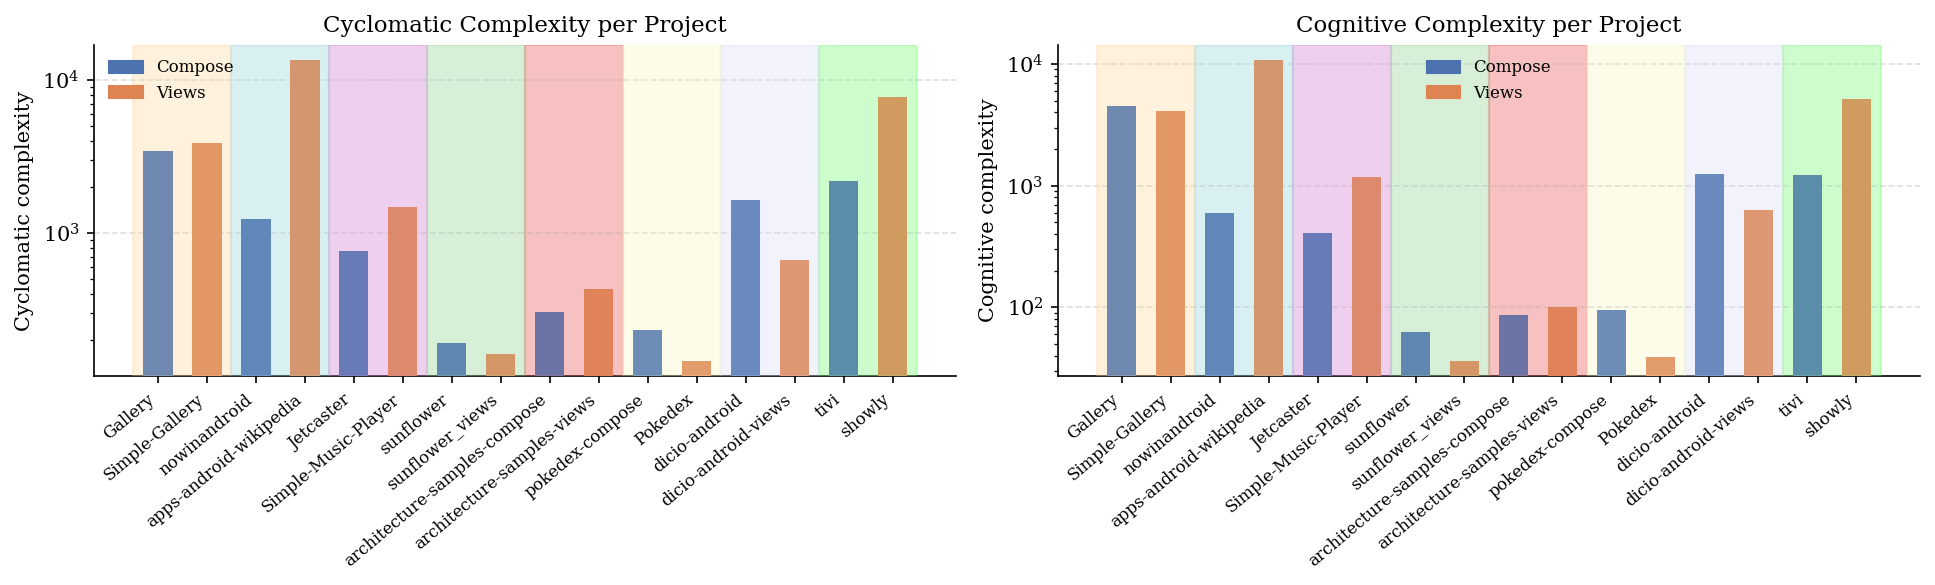

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

paired_bar(axes[0], 'sq_complexity',
           ylabel='Cyclomatic complexity',
           title='Cyclomatic Complexity per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'sq_cognitive_complexity',
           ylabel='Cognitive complexity',
           title='Cognitive Complexity per Project',
           pairs=PAIRS, df=df, log=True)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'complexity.pdf')
plt.show()

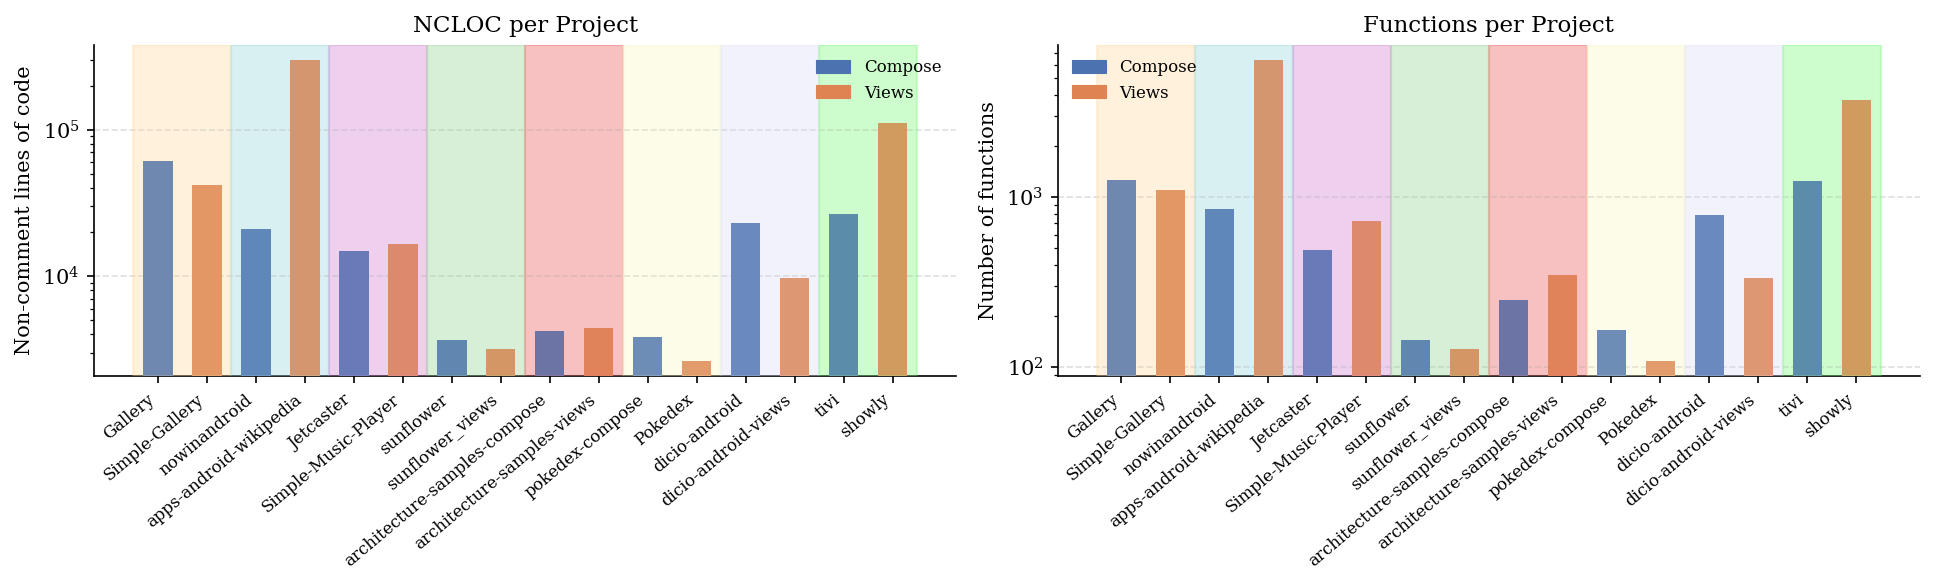

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

paired_bar(axes[0], 'sq_ncloc',
           ylabel='Non-comment lines of code',
           title='NCLOC per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'sq_functions',
           ylabel='Number of functions',
           title='Functions per Project',
           pairs=PAIRS, df=df, log=True)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'size.pdf')
plt.show()

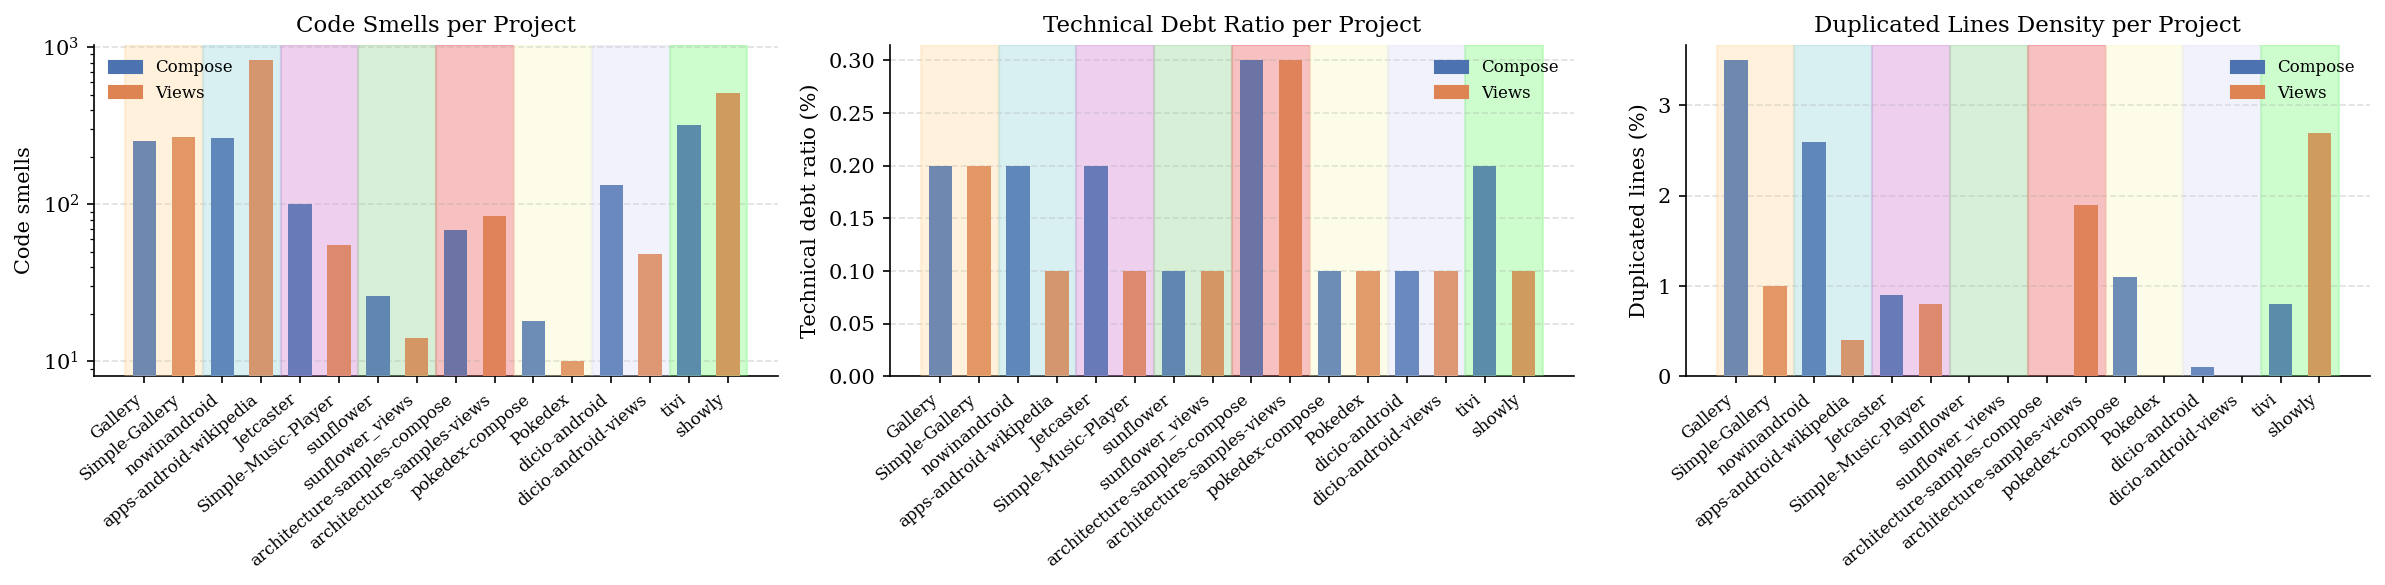

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

paired_bar(axes[0], 'sq_code_smells',
           ylabel='Code smells',
           title='Code Smells per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'sq_sqale_debt_ratio',
           ylabel='Technical debt ratio (%)',
           title='Technical Debt Ratio per Project',
           pairs=PAIRS, df=df)

paired_bar(axes[2], 'sq_duplicated_lines_density',
           ylabel='Duplicated lines (%)',
           title='Duplicated Lines Density per Project',
           pairs=PAIRS, df=df)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'quality.pdf')
plt.show()

### Halstead metrics

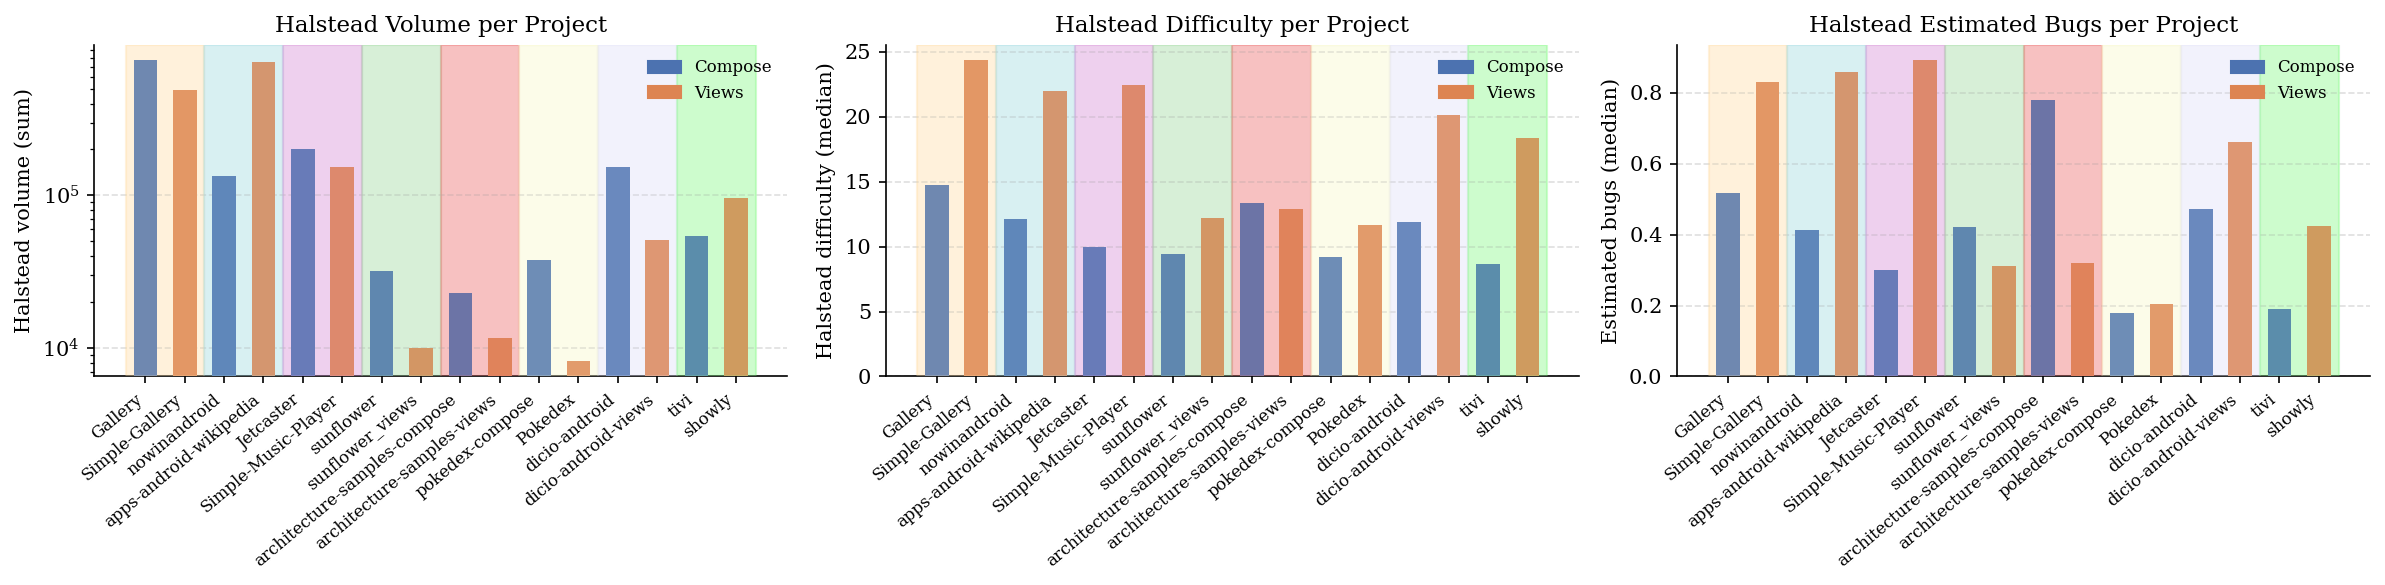

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

paired_bar(axes[0], 'hal_volume',
           ylabel='Halstead volume (sum)',
           title='Halstead Volume per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'hal_difficulty',
           ylabel='Halstead difficulty (median)',
           title='Halstead Difficulty per Project',
           pairs=PAIRS, df=df)

paired_bar(axes[2], 'hal_bugs_delivered',
           ylabel='Estimated bugs (median)',
           title='Halstead Estimated Bugs per Project',
           pairs=PAIRS, df=df)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'halstead.pdf')
plt.show()

### State metrics

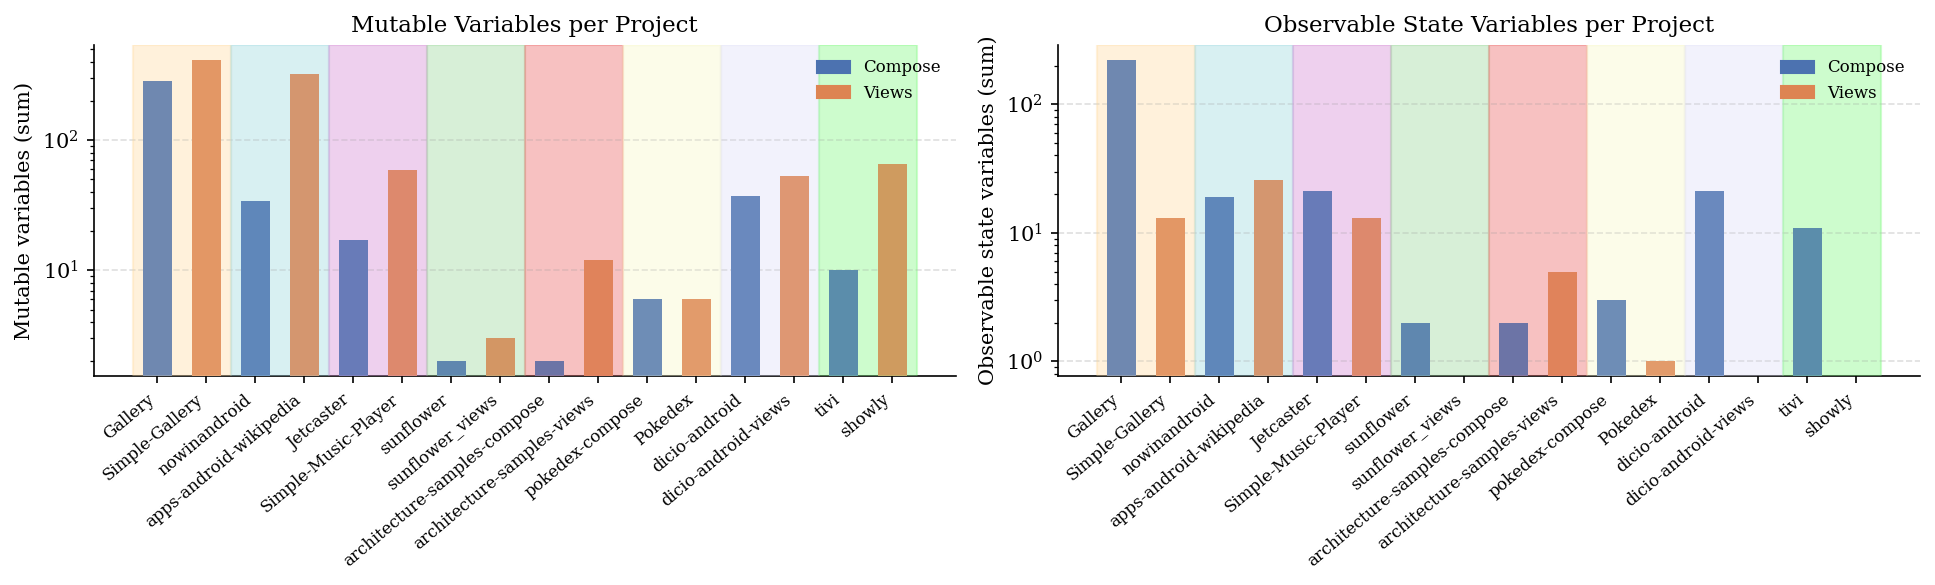

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

paired_bar(axes[0], 'state_mutable_vars',
           ylabel='Mutable variables (sum)',
           title='Mutable Variables per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'state_observable_state_vars',
           ylabel='Observable state variables (sum)',
           title='Observable State Variables per Project',
           pairs=PAIRS, df=df, log=True)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'state.pdf')
plt.show()

### Derived metrics

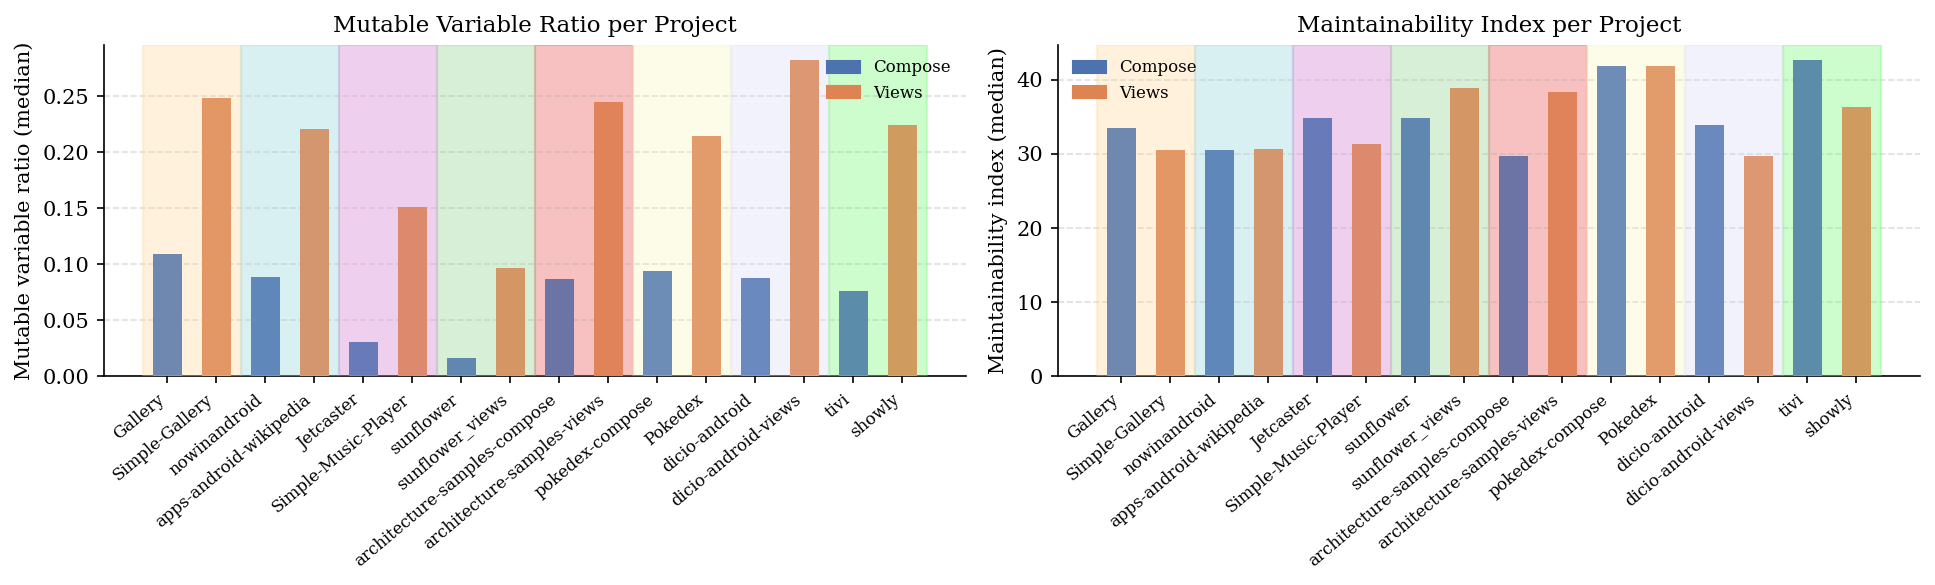

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

paired_bar(axes[0], 'derived_mutable_variable_ratio',
           ylabel='Mutable variable ratio (median)',
           title='Mutable Variable Ratio per Project',
           pairs=PAIRS, df=df)

paired_bar(axes[1], 'derived_maintainability_index',
           ylabel='Maintainability index (median)',
           title='Maintainability Index per Project',
           pairs=PAIRS, df=df)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'derived.pdf')
plt.show()

## Export to CSV

In [18]:
out_path = RESULTS_DIR / 'metrics_table.csv'
df.to_csv(out_path)
print(f'Saved to {out_path}')

Saved to ../results/metrics_table.csv


## Statistical Analysis — Paired Wilcoxon Tests

In [19]:
from scipy import stats as scipy_stats

METRIC_CATEGORIES = {
    'Structural': [
        'sq_complexity', 'sq_cognitive_complexity',
        'sq_code_smells', 'sq_bugs', 'sq_sqale_debt_ratio',
        'sq_duplicated_lines_density', 'derived_maintainability_index',
        'hal_vocabulary', 'hal_length', 'hal_volume', 'hal_calculated_length',
        'hal_difficulty', 'hal_effort', 'hal_bugs_delivered',
    ],
    'Size-based': [
        'sq_ncloc', 'sq_lines', 'sq_files', 'sq_statements',
        'sq_comment_lines', 'sq_comment_lines_density',
        'sq_functions', 'sq_classes',
    ],
    'State-related': [
        'state_mutable_vars', 'state_immutable_vars',
        'state_observable_state_vars', 'state_state_updates',
        'derived_mutable_variable_ratio',
    ],
}


def get_paired_values(metric):
    """Return (a_vals, b_vals, pair_labels) aligned by pair order."""
    a_vals, b_vals, labels = [], [], []
    for fw_a, proj_a, _, fw_b, proj_b, _, _ in PAIRS:
        idx_a = (fw_a, proj_a)
        idx_b = (fw_b, proj_b) if fw_b else None
        if idx_a not in df.index or idx_b not in df.index:
            continue
        va = df.loc[idx_a, metric]
        vb = df.loc[idx_b, metric]
        if pd.isna(va) or pd.isna(vb):
            continue
        a_vals.append(float(va))
        b_vals.append(float(vb))
        labels.append(f'{proj_a} vs {proj_b}')
    return np.array(a_vals), np.array(b_vals), labels


def wilcoxon_test(a_vals, b_vals):
    if len(a_vals) < 3:
        return None, None, None
    diffs = a_vals - b_vals
    if np.all(diffs == 0):
        return 1.0, 0.0, 'negligible'
    try:
        stat, p = scipy_stats.wilcoxon(a_vals, b_vals, alternative='two-sided')
    except ValueError:
        return None, None, None
    n = len(a_vals)
    r = 1 - (2 * stat) / (n * (n + 1) / 2)
    magnitude = 'large' if abs(r) >= 0.5 else ('medium' if abs(r) >= 0.3 else ('small' if abs(r) >= 0.1 else 'negligible'))
    return p, r, magnitude


results = []
for category, metrics in METRIC_CATEGORIES.items():
    for metric in metrics:
        if metric not in df.columns:
            continue
        a_vals, b_vals, _ = get_paired_values(metric)
        if len(a_vals) == 0:
            continue
        compose_mean = np.mean(a_vals)
        compose_std  = np.std(a_vals, ddof=1)
        views_mean   = np.mean(b_vals)
        views_std    = np.std(b_vals, ddof=1)
        p, r, mag    = wilcoxon_test(a_vals, b_vals)
        results.append({
            'category':     category,
            'metric':       metric,
            'compose_mean': compose_mean,
            'compose_std':  compose_std,
            'views_mean':   views_mean,
            'views_std':    views_std,
            'p_value':      p,
            'effect_r':     r,
            'effect_size':  mag,
            'n_pairs':      len(a_vals),
        })

stats_df = pd.DataFrame(results)
print(f'{len(stats_df)} metrics tested across {len(METRIC_CATEGORIES)} categories')

27 metrics tested across 3 categories


### Results table

Compose = declarative side, Views = imperative side.  
p < 0.05 = statistically significant difference.  
Effect size r: negligible < 0.1, small 0.1–0.3, medium 0.3–0.5, large > 0.5.

In [20]:
def fmt_mean_std(mean, std):
    if pd.isna(mean): return '—'
    return f'{mean:.1f} ± {std:.1f}'

def fmt_p(p):
    if p is None or pd.isna(p): return '—'
    if p < 0.001: return '< 0.001 ***'
    if p < 0.01:  return f'{p:.3f} **'
    if p < 0.05:  return f'{p:.3f} *'
    return f'{p:.3f}'

display_rows = []
for _, row in stats_df.iterrows():
    p = row['p_value']
    significant = (p is not None) and (not pd.isna(p)) and (p < 0.05)
    display_rows.append({
        'Category':          row['category'],
        'Metric':            row['metric'],
        'Compose (mean±sd)': fmt_mean_std(row['compose_mean'], row['compose_std']),
        'Views (mean±sd)':   fmt_mean_std(row['views_mean'],   row['views_std']),
        'p-value':           fmt_p(p),
        'r':                 f"{row['effect_r']:.2f}" if row['effect_r'] is not None and not pd.isna(row['effect_r']) else '—',
        'Effect':            row['effect_size'] if row['effect_size'] else '—',
        'n':                 int(row['n_pairs']),
        'Significant':       'Yes' if significant else 'No',
    })

display_df = pd.DataFrame(display_rows).set_index(['Category', 'Metric'])
display_df


Compose (mean±sd)  \
Category      Metric                                                
Structural    sq_complexity                       1251.4 ± 1140.3   
              sq_cognitive_complexity             1027.0 ± 1482.6   
              sq_code_smells                        148.0 ± 116.7   
              sq_bugs                                   3.4 ± 7.3   
              sq_sqale_debt_ratio                       0.2 ± 0.1   
              sq_duplicated_lines_density               1.1 ± 1.3   
              derived_maintainability_index            35.2 ± 4.7   
              hal_vocabulary                      6341.6 ± 8291.5   
              hal_length                        25139.5 ± 34956.7   
              hal_volume                      176585.8 ± 251350.6   
              hal_calculated_length                 362.3 ± 136.5   
              hal_difficulty                           11.2 ± 2.2   
              hal_effort                        15744.2 ± 10772.9   
              hal_bugs_delivered                        0.4 ± 0.2   
Size-based    sq_ncloc                          19787.9 ± 19014.0   
              sq_lines                          26077.9 ± 21061.7   
              sq_files                              320.8 ± 226.9   
              sq_statements                       3862.5 ± 3493.5   
              sq_comment_lines                     1415.1 ± 878.5   
              sq_comment_lines_density                  9.7 ± 5.1   
              sq_functions                          649.6 ± 459.6   
              sq_classes                            271.2 ± 249.0   
State-related state_mutable_vars                      49.2 ± 96.6   
              state_immutable_vars                  489.0 ± 762.5   
              state_observable_state_vars             37.8 ± 75.3   
              state_state_updates                    93.5 ± 189.2   
              derived_mutable_variable_ratio            0.1 ± 0.0   

                                                  Views (mean±sd)   p-value  \
Category      Metric                                                          
Structural    sq_complexity                       3502.5 ± 4822.4     0.250   
              sq_cognitive_complexity             2766.9 ± 3819.6     0.641   
              sq_code_smells                        228.6 ± 299.7     0.641   
              sq_bugs                                   2.5 ± 2.7     1.000   
              sq_sqale_debt_ratio                       0.1 ± 0.1     0.250   
              sq_duplicated_lines_density               0.8 ± 1.0     0.469   
              derived_maintainability_index            34.7 ± 4.7     0.844   
              hal_vocabulary                      5801.0 ± 7504.8     0.383   
              hal_length                        25207.1 ± 34569.5     0.461   
              hal_volume                      196459.6 ± 275465.4     0.461   
              hal_calculated_length                 476.0 ± 183.9     0.312   
              hal_difficulty                           18.0 ± 5.1   0.016 *   
              hal_effort                        34579.5 ± 23594.9     0.055   
              hal_bugs_delivered                        0.6 ± 0.3     0.250   
Size-based    sq_ncloc                         61544.5 ± 103896.6     0.844   
              sq_lines                         68697.5 ± 111479.5     0.844   
              sq_files                              650.1 ± 888.6     1.000   
              sq_statements                      9970.4 ± 13718.0     0.844   
              sq_comment_lines                    1306.0 ± 1568.7     0.547   
              sq_comment_lines_density                  9.1 ± 9.5     0.844   
              sq_functions                        1610.8 ± 2282.2     0.547   
              sq_classes                            530.5 ± 842.2     0.844   
State-related state_mutable_vars                    117.2 ± 159.6   0.016 *   
              state_immutable_vars                  397.6 ± 507.5     0

### Statistics table — thesis figure

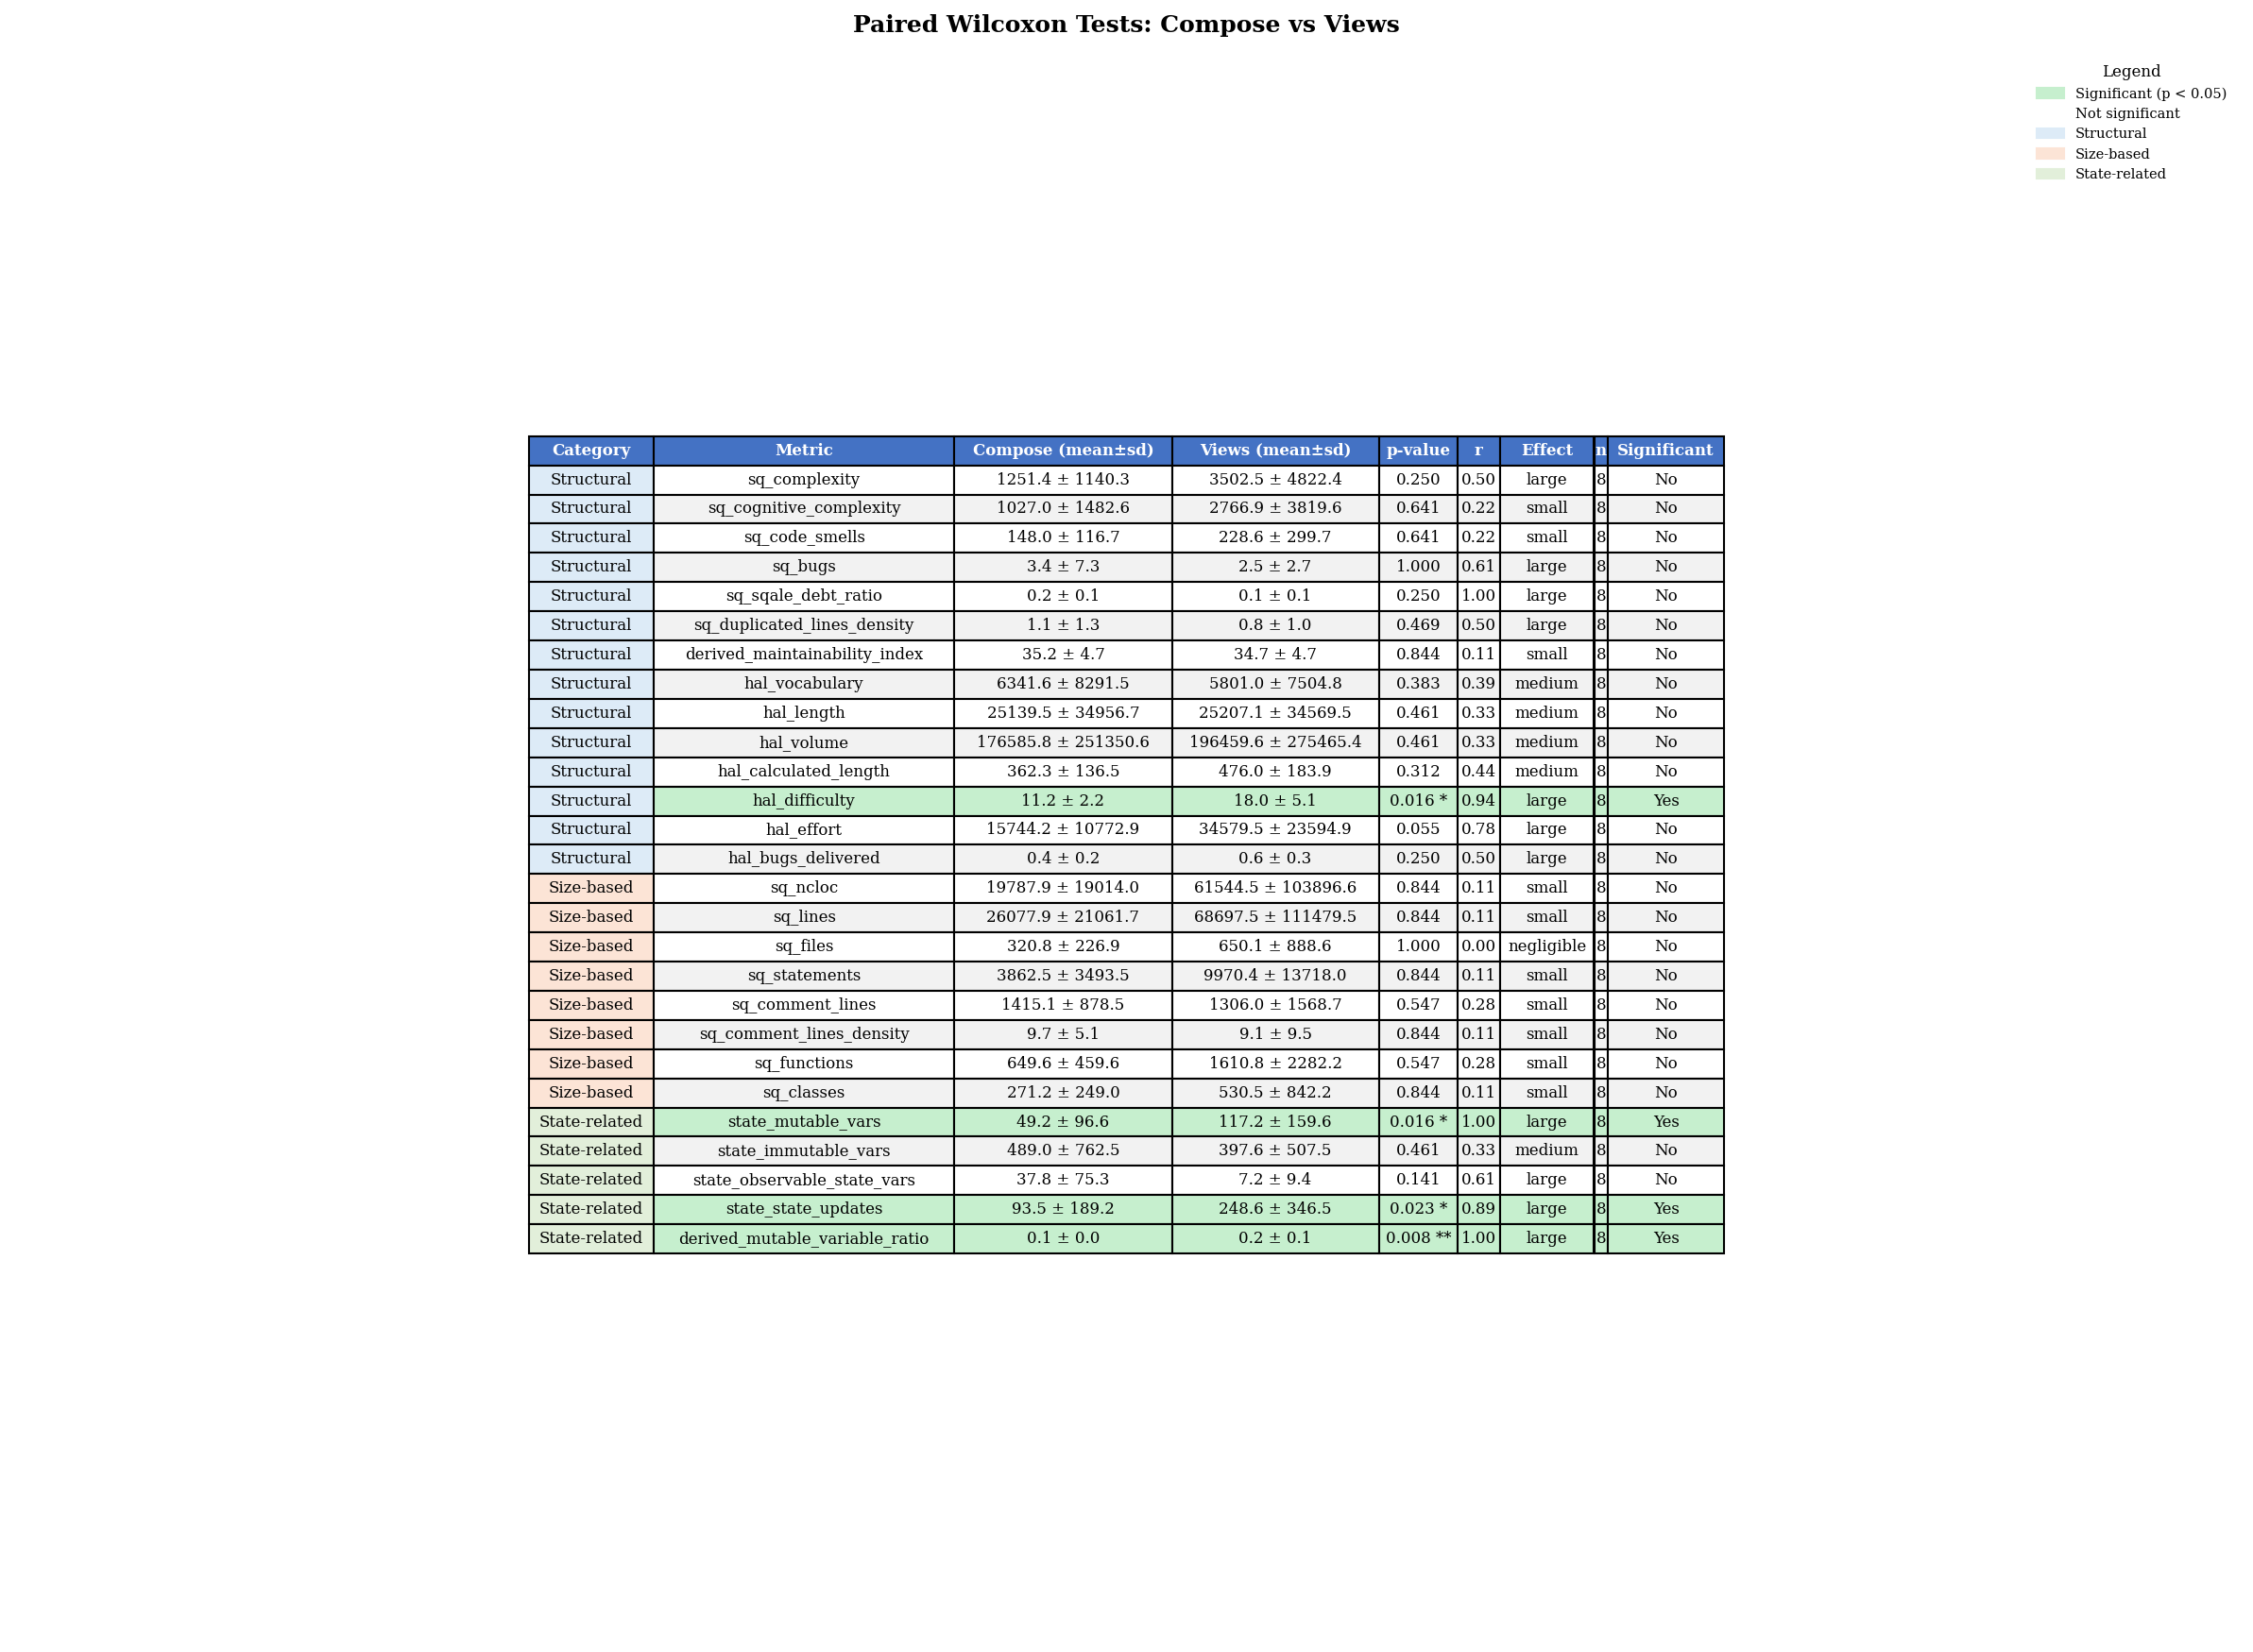

In [21]:
HEADER_COLOR = '#4472C4'
SIG_COLOR    = '#C6EFCE'
NONSIG_COLOR = '#FFFFFF'
ALT_COLOR    = '#F2F2F2'
CAT_COLORS = {
    'Structural':    '#DDEBF7',
    'Size-based':    '#FCE4D6',
    'State-related': '#E2EFDA',
}

cols = ['Compose (mean±sd)', 'Views (mean±sd)', 'p-value', 'r', 'Effect', 'n', 'Significant']
table_df = display_df.reset_index()

cell_text, cell_colors = [], []
col_headers = ['Category', 'Metric'] + cols

for i, row in table_df.iterrows():
    text_row  = [row['Category'], row['Metric']] + [str(row[c]) for c in cols]
    sig       = row['Significant'] == 'Yes'
    base_col  = SIG_COLOR if sig else (NONSIG_COLOR if i % 2 == 0 else ALT_COLOR)
    cat_col   = CAT_COLORS.get(row['Category'], '#FFFFFF')
    color_row = [cat_col, base_col] + [base_col] * len(cols)
    cell_text.append(text_row)
    cell_colors.append(color_row)

n_rows = len(cell_text)
n_cols = len(col_headers)
fig_h  = max(4, n_rows * 0.38 + 1.5)
fig, ax = plt.subplots(figsize=(16, fig_h))
ax.axis('off')

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_headers,
    cellColours=cell_colors,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.auto_set_column_width(col=list(range(n_cols)))

for j in range(n_cols):
    tbl[0, j].set_facecolor(HEADER_COLOR)
    tbl[0, j].set_text_props(color='white', fontweight='bold')

sig_patch    = mpatches.Patch(color=SIG_COLOR,    label='Significant (p < 0.05)')
nonsig_patch = mpatches.Patch(color=NONSIG_COLOR, label='Not significant', linewidth=0.5)
cat_patches  = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
ax.legend(handles=[sig_patch, nonsig_patch] + cat_patches,
          loc='upper right', fontsize=7, title='Legend', title_fontsize=8)

plt.title('Paired Wilcoxon Tests: Compose vs Views', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
# plt.savefig(FIGURES_DIR / 'stats_table.png', dpi=300, bbox_inches='tight')
plt.show()

### Mean difference: Imperative − Declarative

Each bar shows `(Views mean − Compose mean) / midpoint × 100%`.  
Bars **above zero** → imperative (Views) had the larger value.  
Bars **below zero** → declarative (Compose) had the larger value.  
`*` marks metrics that are statistically significant (p < 0.05).

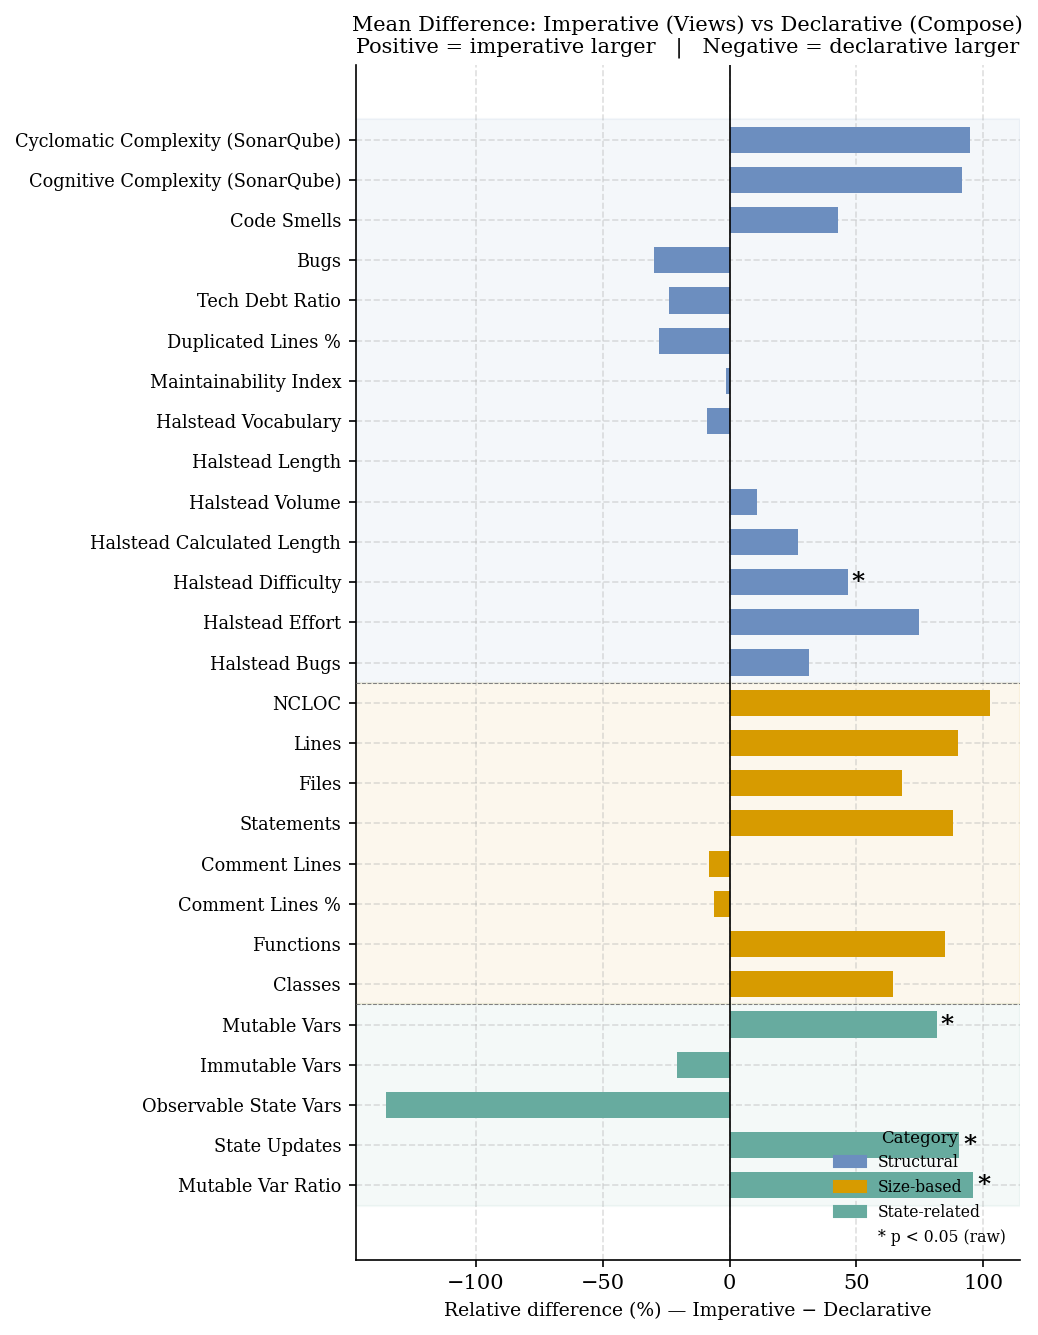

In [22]:
METRIC_LABELS = {
    'sq_complexity':               'Cyclomatic Complexity (SonarQube)',
    'sq_cognitive_complexity':     'Cognitive Complexity (SonarQube)',
    'sq_code_smells':              'Code Smells',
    'sq_bugs':                     'Bugs',
    'sq_sqale_debt_ratio':         'Tech Debt Ratio',
    'sq_duplicated_lines_density': 'Duplicated Lines %',
    'derived_maintainability_index': 'Maintainability Index',
    'hal_vocabulary':              'Halstead Vocabulary',
    'hal_length':                  'Halstead Length',
    'hal_volume':                  'Halstead Volume',
    'hal_calculated_length':       'Halstead Calculated Length',
    'hal_difficulty':              'Halstead Difficulty',
    'hal_effort':                  'Halstead Effort',
    'hal_bugs_delivered':          'Halstead Bugs',
    'sq_ncloc':                    'NCLOC',
    'sq_lines':                    'Lines',
    'sq_files':                    'Files',
    'sq_statements':               'Statements',
    'sq_comment_lines':            'Comment Lines',
    'sq_comment_lines_density':    'Comment Lines %',
    'sq_functions':                'Functions',
    'sq_classes':                  'Classes',
    'state_mutable_vars':          'Mutable Vars',
    'state_immutable_vars':        'Immutable Vars',
    'state_observable_state_vars': 'Observable State Vars',
    'state_state_updates':         'State Updates',
    'derived_mutable_variable_ratio': 'Mutable Var Ratio',
}

CAT_BAR_COLORS = {
    'Structural':    '#6C8EBF',
    'Size-based':    '#D79B00',
    'State-related': '#67AB9F',
}

category_order = ['Structural', 'Size-based', 'State-related']


def get_paired_values_raw(metric):
    a_vals, b_vals = [], []
    for fw_a, proj_a, _, fw_b, proj_b, _, _ in PAIRS:
        idx_a = (fw_a, proj_a)
        idx_b = (fw_b, proj_b)
        if idx_a not in df.index or idx_b not in df.index:
            continue
        va = df.loc[idx_a, metric]
        vb = df.loc[idx_b, metric]
        if pd.isna(va) or pd.isna(vb):
            continue
        a_vals.append(float(va))
        b_vals.append(float(vb))
    return np.array(a_vals), np.array(b_vals)


plot_rows = []
for cat, metrics in METRIC_CATEGORIES.items():
    for metric in metrics:
        if metric not in df.columns:
            continue
        a_vals, b_vals = get_paired_values_raw(metric)
        if len(a_vals) == 0:
            continue
        compose_mean = np.mean(a_vals)
        views_mean   = np.mean(b_vals)
        midpoint     = (compose_mean + views_mean) / 2
        diff_pct     = (views_mean - compose_mean) / midpoint * 100 if midpoint != 0 else 0.0

        row_stats = stats_df[stats_df['metric'] == metric]
        p_value   = row_stats['p_value'].values[0] if len(row_stats) else None

        plot_rows.append({
            'category': cat,
            'metric':   metric,
            'diff_pct': diff_pct,
            'p_value':  p_value,
        })

cat_rank = {c: i for i, c in enumerate(category_order)}
plot_rows.sort(key=lambda r: (cat_rank.get(r['category'], 99),
                               list(METRIC_CATEGORIES.get(r['category'], [])).index(r['metric'])
                               if r['metric'] in METRIC_CATEGORIES.get(r['category'], []) else 99))

labels    = [METRIC_LABELS.get(r['metric'], r['metric']) for r in plot_rows]
values    = [r['diff_pct'] for r in plot_rows]
colors    = [CAT_BAR_COLORS[r['category']] for r in plot_rows]
sig_flags = [r['p_value'] is not None and not pd.isna(r['p_value']) and r['p_value'] < 0.05
             for r in plot_rows]

fig, ax = plt.subplots(figsize=(7, 9))

ax.barh(range(len(labels)), values, color=colors, height=0.65, zorder=3)

for i, (val, sig) in enumerate(zip(values, sig_flags)):
    if sig:
        x_offset = 1.5 if val >= 0 else -1.5
        ha = 'left' if val >= 0 else 'right'
        ax.text(val + x_offset, i, '*', va='center', ha=ha,
                fontsize=12, fontweight='bold', color='black')

ax.axvline(0, color='black', linewidth=0.8, zorder=5)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8.5)
ax.invert_yaxis()

ax.set_xlabel('Relative difference (%) — Imperative − Declarative', fontsize=9)
ax.set_title('Mean Difference: Imperative (Views) vs Declarative (Compose)\n'
             'Positive = imperative larger   |   Negative = declarative larger',
             fontsize=10)

cat_sizes   = [sum(1 for r in plot_rows if r['category'] == c) for c in category_order]
cat_patches = [mpatches.Patch(color=CAT_BAR_COLORS[c], label=c) for c in category_order]
sig_marker  = mpatches.Patch(color='none', label='* p < 0.05 (raw)')
ax.legend(handles=cat_patches + [sig_marker], fontsize=7.5,
          loc='lower right', title='Category', title_fontsize=8)

sep = 0
for size in cat_sizes[:-1]:
    sep += size
    ax.axhline(sep - 0.5, color='grey', linewidth=0.5, linestyle='--', zorder=4)

sep = 0
for cat, size in zip(category_order, cat_sizes):
    ax.axhspan(sep - 0.5, sep + size - 0.5,
               color=CAT_BAR_COLORS[cat], alpha=0.07, zorder=0)
    sep += size

ax.grid(True, axis='x', alpha=0.4, linestyle='--')
ax.set_axisbelow(True)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'mean_difference.pdf')
plt.show()